In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
plt.style.use('thesis')
import pickle as pkl

Definition of two-labels model: 

- Bin 1: Young stars (5 Myr and younger)
- Bin 2: Old stars (5 Myr to 14.1 Gyr)

In [2]:
f = np.load('/home/vmehta/honours-project/code/data/sfh_twobins_spectra.npy')
wavs = np.load(f"/home/vmehta/honours-project/code/data/wavelengths.npy")

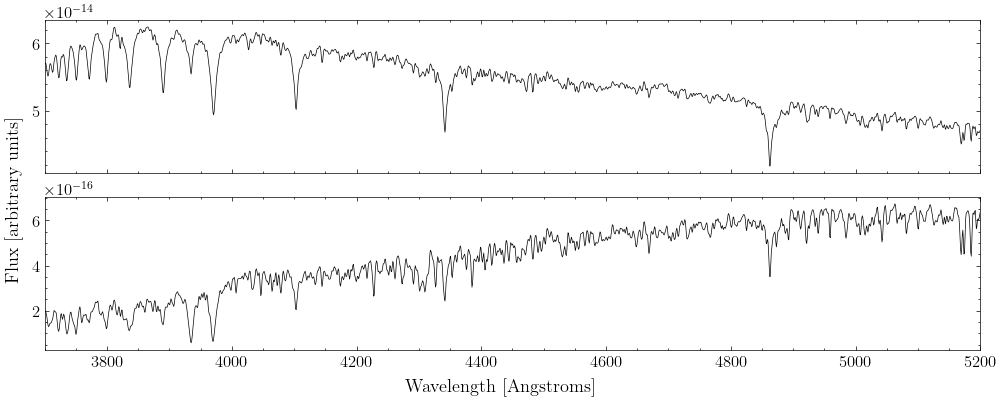

In [3]:
fig, ax = plt.subplots(2, 1, figsize=(10,4), sharex=True, constrained_layout=True)
for i, s in enumerate(f):
    ax[i].plot(wavs, s, 'k', linewidth=0.5)

ax[0].set_xlim(3700,5200)
fig.supylabel('Flux [arbitrary units]')
fig.supxlabel('Wavelength [Angstroms]')

#plt.savefig('/home/vmehta/honours-project/thesis/figures/sfh_averages.pdf', format='pdf')
plt.show()

In [45]:
# define functions for this notebook
file = "sfh_1000_2bins_20260323_140648"

def get_linear_coeffs(snr, which):
    if which == "log":
        model = pkl.load(open(f"/avatar/vmehta/{file}/log-model/snr{snr}_model.pkl", "rb"))
    if which == "bounds":
        model = pkl.load(open(f"/avatar/vmehta/{file}/bounds-model/snr{snr}_model.pkl", "rb"))
    if which == "linear":
        model = pkl.load(open(f"/avatar/vmehta/{file}/linear-model/snr{snr}_model.pkl", "rb"))
    if which == "prior":
        model = pkl.load(open(f"/avatar/vmehta/{file}/prior-model/snr{snr}_model.pkl", "rb"))
    if which == "log-prior":
        model = pkl.load(open(f"/avatar/vmehta/{file}/log-prior-model/snr{snr}_model.pkl", "rb"))
    if which == "linear-prior":
        model = pkl.load(open(f"/avatar/vmehta/{file}/linear-prior-model/snr{snr}_model.pkl", "rb"))
    if which == None:
        model = pkl.load(open(f"/avatar/vmehta/{file}/snr{snr}_model.pkl", "rb"))
    return model['theta'][:,1:3]

def plot_coeffs(which):
    fig, ax = plt.subplots(2, 3, figsize=(10,5), sharex=True, sharey='row')

    for n, s in enumerate([1000, 500, 100]):
        for i in range(2):
            ax[i, n].plot(wavs, get_linear_coeffs(s, which)[:,i], linewidth=0.2, color='k')

    ax[0,0].set_title("SNR = 1000")
    ax[0,1].set_title("SNR = 500")
    ax[0,2].set_title("SNR = 100")

    plt.tight_layout()
    plt.show()

    return

def get_labels(snr, which):
    if which == "log":
        model = np.load(f"/avatar/vmehta/{file}/log-model/snr{snr}_pred.npy")
        true = np.load(f"/avatar/vmehta/{file}/log-model/snr1000_true.npy")
    if which == "linear":
        model = np.load(f"/avatar/vmehta/{file}/linear-model/snr{snr}_pred.npy")
        true = np.load(f"/avatar/vmehta/{file}/linear-model/snr1000_true.npy")
    if which == "log-prior":
        model = np.load(f"/avatar/vmehta/{file}/log-prior-model/snr{snr}_pred.npy")
        true = np.load(f"/avatar/vmehta/{file}/log-prior-model/snr1000_true.npy")
    if which == "linear-prior":
        model = np.load(f"/avatar/vmehta/{file}/linear-prior-model/snr{snr}_pred.npy")
        true = np.load(f"/avatar/vmehta/{file}/linear-prior-model/snr1000_true.npy")
    if which == "bounds":
        model = np.load(f"/avatar/vmehta/{file}/bounds-model/snr{snr}_pred.npy")
        true = np.load(f"/avatar/vmehta/{file}/bounds-model/snr1000_true.npy")
    if which == "prior":
        model = np.load(f"/avatar/vmehta/{file}/prior-model/snr{snr}_pred.npy")
        true = np.load(f"/avatar/vmehta/{file}/prior-model/snr1000_true.npy")
    if which == None:
        model = np.load(f"/avatar/vmehta/{file}/snr{snr}_pred.npy")
        true = np.load(f"/avatar/vmehta/{file}/snr1000_true.npy")
    return model, true

def plot_labels(which):
    fig, ax = plt.subplots(1, 2, figsize=(10,4), sharex=True, sharey=True)

    for s in [100, 500, 1000]:
        for i in range(2):
            ax[i].plot(get_labels(s, which)[1][:,i], get_labels(s, which)[0][:,i], '.', alpha=0.5, markersize=5)

    # ax[0].set_xlim(-0.05,1)
    # ax[0].set_ylim(-0.05,1)
    ax[1].legend(["SNR = 100", "SNR = 500", "SNR = 1000"], loc='lower right')
    ax[0].set_title("Young")
    ax[1].set_title("Old")

    plt.tight_layout()
    plt.show()

    return

## Log-model
First check current model performance i.e. keeping log-labels and label generation the same (no prior). Use same set of 1000 spectra.

/tmp/ipykernel_976600/1672813276.py:6: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  model = pkl.load(open(f"/avatar/vmehta/{file}/log-model/snr{snr}_model.pkl", "rb"))


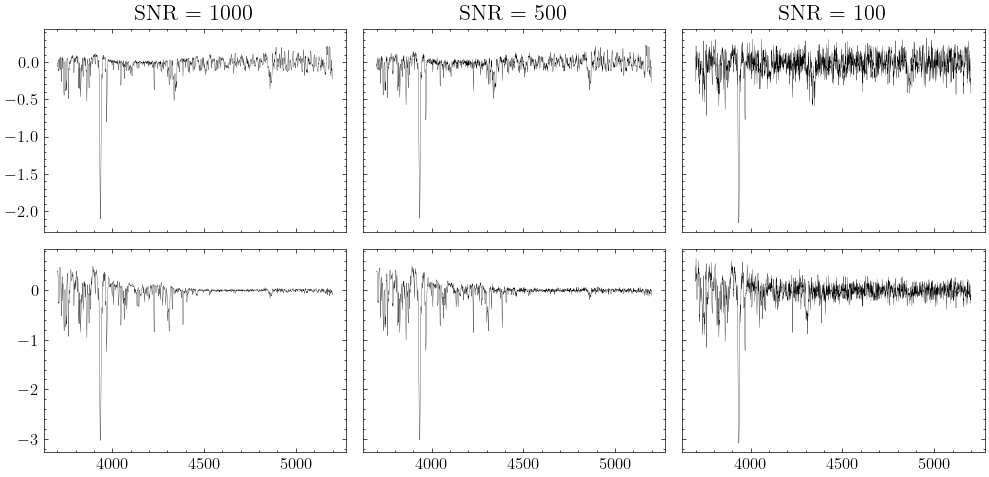

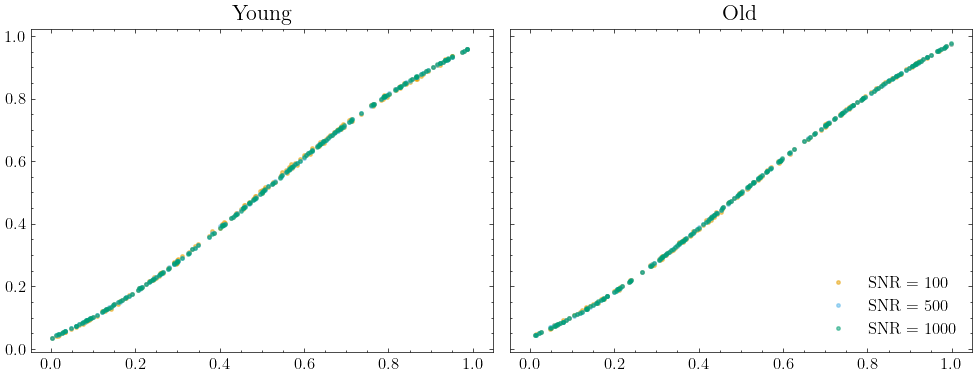

In [33]:
plot_coeffs(which="log")
plot_labels(which="log")

/tmp/ipykernel_976600/3653816144.py:12: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  model = pkl.load(open(f"/avatar/vmehta/{file}/log-prior-model/snr{snr}_model.pkl", "rb"))


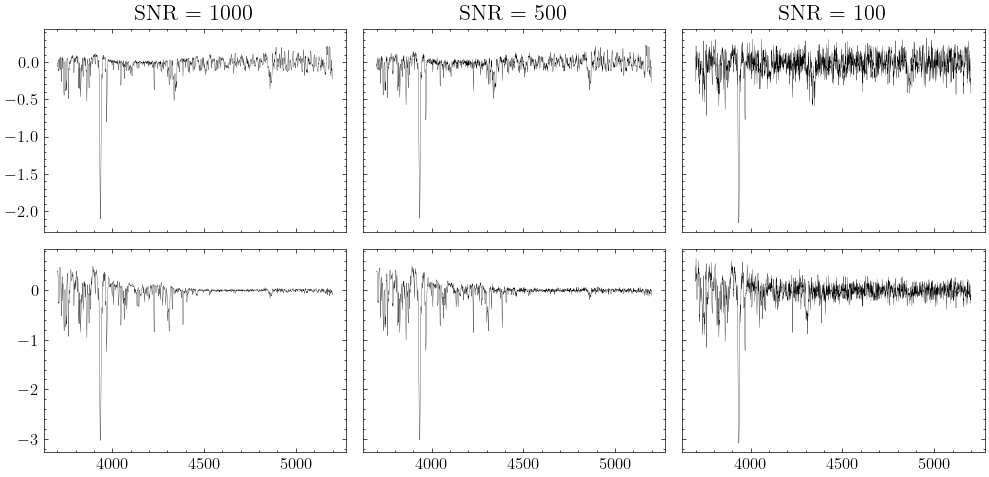

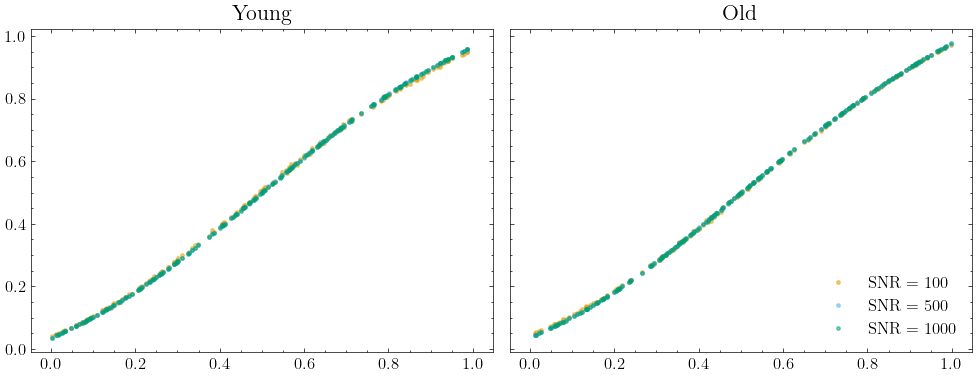

In [43]:
plot_coeffs(which="log-prior")
plot_labels(which="log-prior")

/tmp/ipykernel_976600/441036852.py:10: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  model = pkl.load(open(f"/avatar/vmehta/{file}/linear-model/snr{snr}_model.pkl", "rb"))


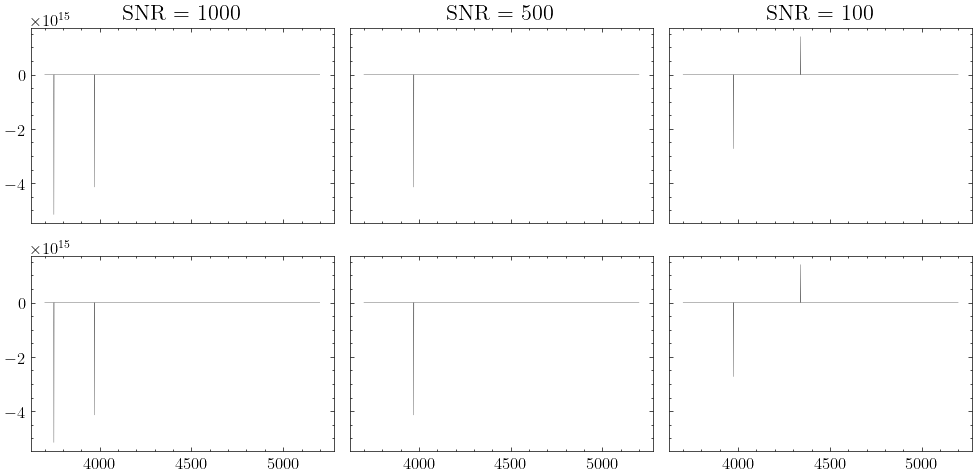

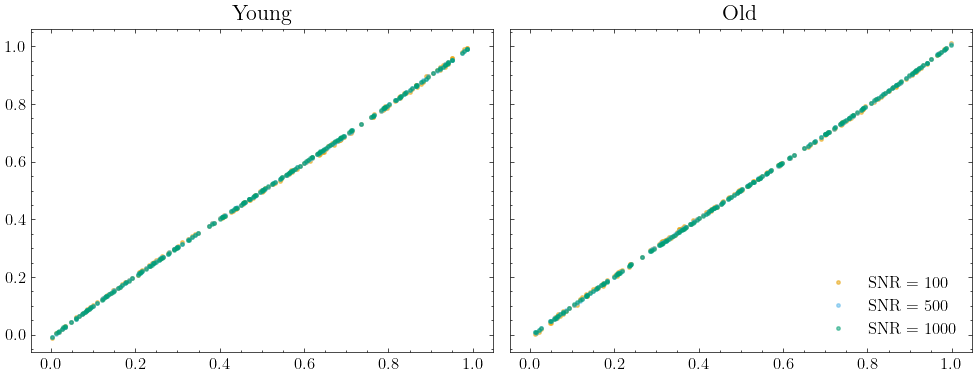

In [46]:
plot_coeffs(which="linear")
plot_labels(which="linear")

/tmp/ipykernel_976600/441036852.py:16: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  model = pkl.load(open(f"/avatar/vmehta/{file}/linear-prior-model/snr{snr}_model.pkl", "rb"))


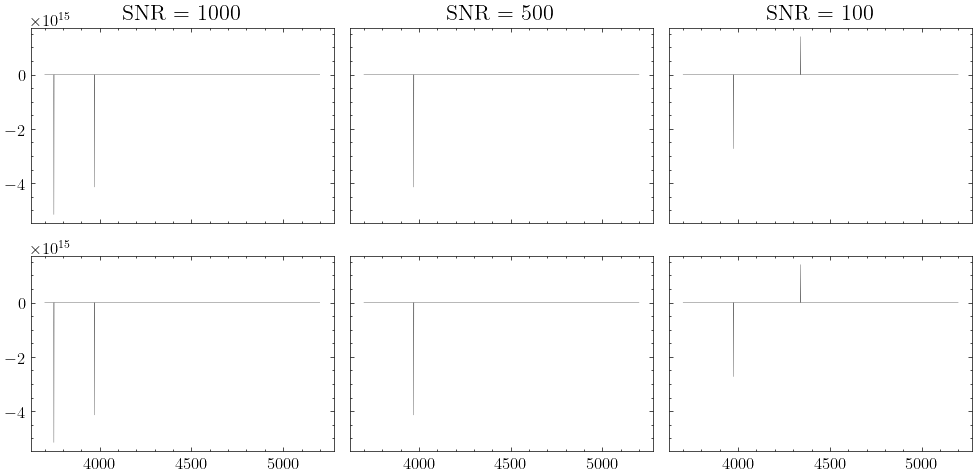

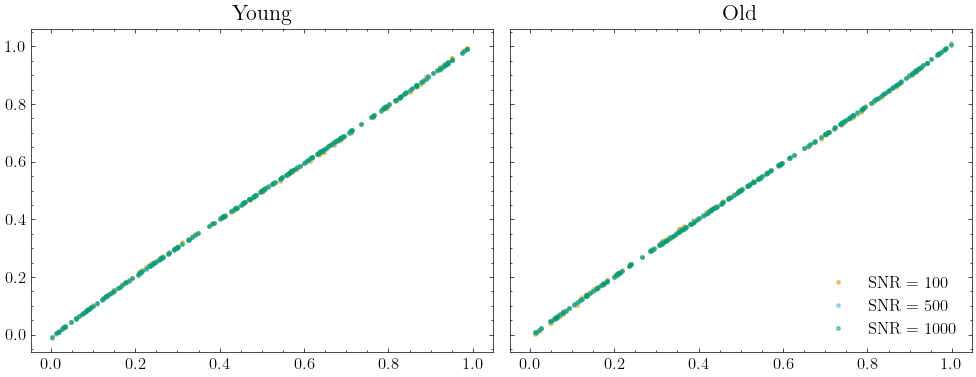

In [47]:
plot_coeffs(which="linear-prior")
plot_labels(which="linear-prior")

## Optimisation bounds
Modify optimisation routine in `fitting.py` from `scipy.optimize.leastsq` to `scipy.optimize.least_squares` as it allows for the specification of bounds. This enforces a hard constraint rather than a soft boundary which was causing problems before.

/tmp/ipykernel_976600/473622089.py:12: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  model = pkl.load(open(f"/avatar/vmehta/{file}/bounds-model/snr{snr}_model.pkl", "rb"))


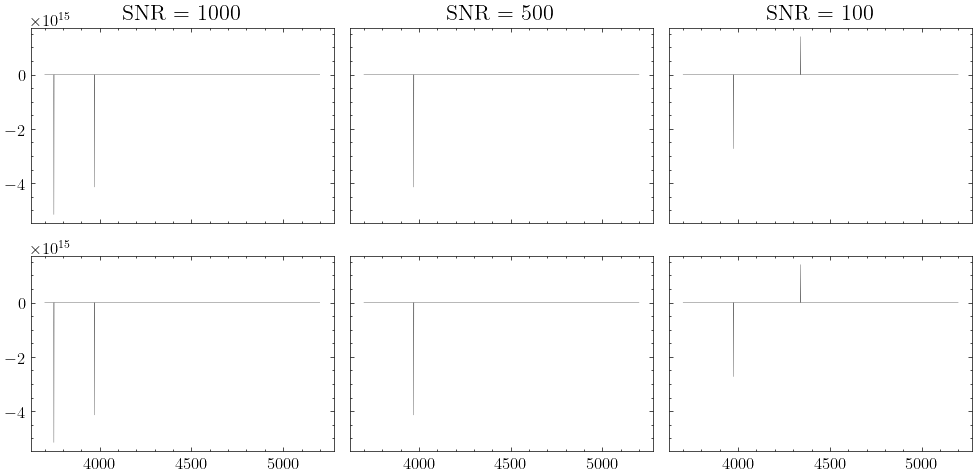

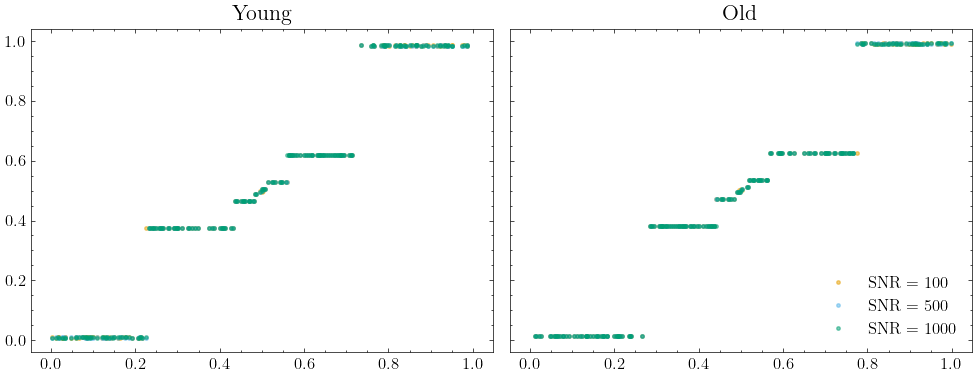

In [18]:
plot_coeffs(which="bounds")
plot_labels(which="bounds")

/tmp/ipykernel_976600/3576652265.py:10: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  model = pkl.load(open(f"/avatar/vmehta/{file}/prior-model/snr{snr}_model.pkl", "rb"))


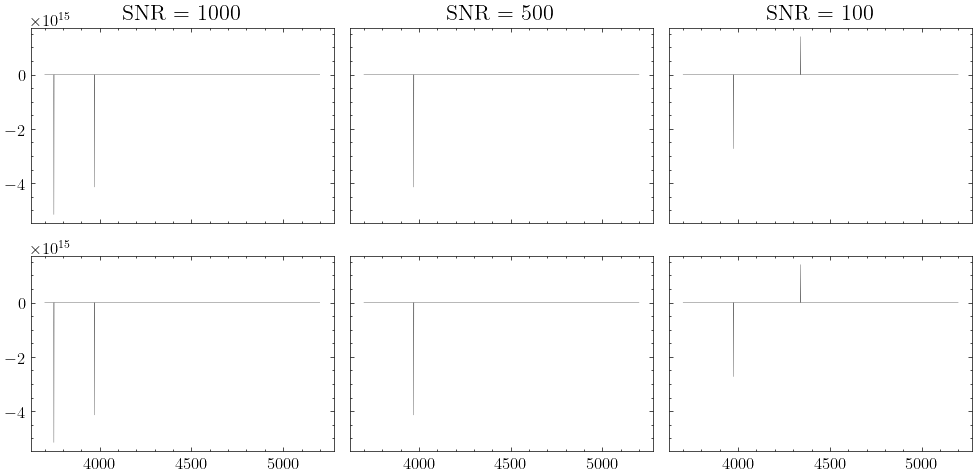

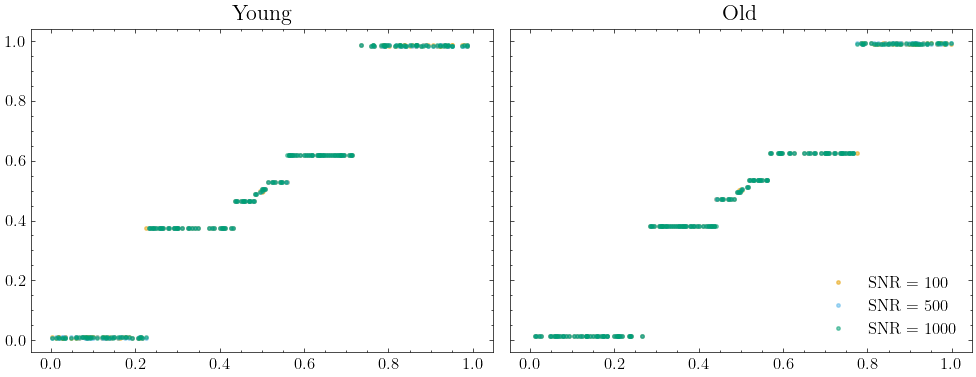

In [31]:
plot_coeffs(which="prior")
plot_labels(which="prior")

## What do the spectra look like?

In [19]:
input_spec = np.load(f"/avatar/vmehta/{file}/{file}_spectra.npy")
pred_100 = np.load(f"/avatar/vmehta/{file}/bounds-model/snr100_pred.npy")
true_100 = np.load(f"/avatar/vmehta/{file}/bounds-model/snr100_true.npy")

In [20]:
def moving_average(x, w):
        """Returns the moving average of the input array."""
        return np.convolve(x, np.ones(w), 'same') / w

def normalize(v):
    s_flat = v / moving_average(v, 100)
    return s_flat * moving_average(np.ones_like(s_flat), 100) - 1  # dealing with edges

norm_vals = [normalize(v) for v in f]

In [21]:
def plot_spec(n):

    print(f'Input Labels = {true_100[n]}')
    print(f'Predicted Labels = {pred_100[n]}')

    fig, ax = plt.subplots(2, 1, figsize=(10,3), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

    ax[0].plot(wavs, pred_100[n]@norm_vals, 'k', linewidth=0.5, label='Spectrum from predicted labels')
    ax[0].plot(wavs, true_100[n]@norm_vals, 'r', linewidth=0.5, label='Spectrum from input labels')
    ax[0].legend(fontsize=10, loc='lower right')
    ax[0].set_title(f'Spectrum at SNR = 100')

    ax[1].plot(wavs, true_100[n]@norm_vals-pred_100[n]@norm_vals, 'k', linewidth=0.5)
    ax[1].set_title('Residuals')

    plt.tight_layout()
    plt.show()

    return

Input Labels = [0.07392693 0.92607307]
Predicted Labels = [0.01059045 0.98940955]


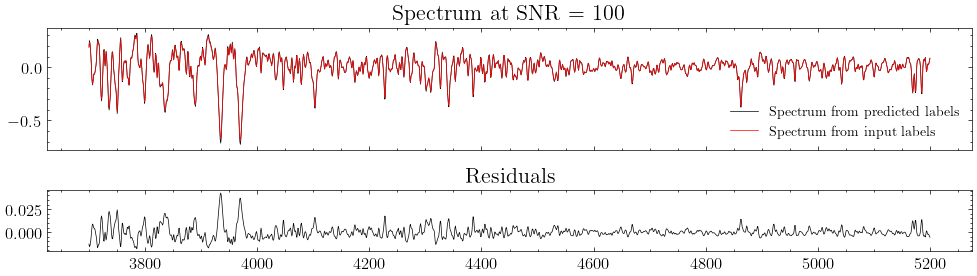

Input Labels = [0.67432533 0.32567467]
Predicted Labels = [0.61883425 0.38116575]


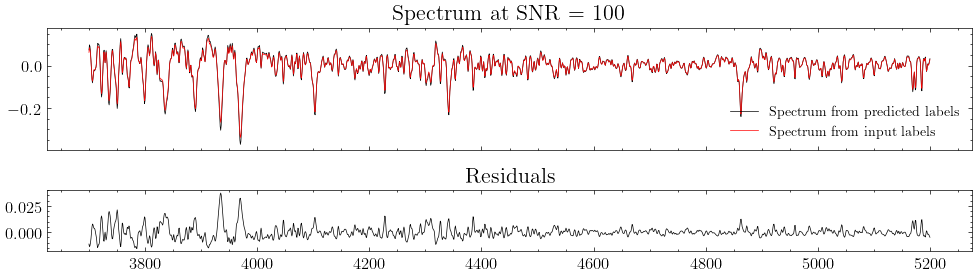

Input Labels = [0.98701201 0.01298799]
Predicted Labels = [0.98582651 0.01417349]


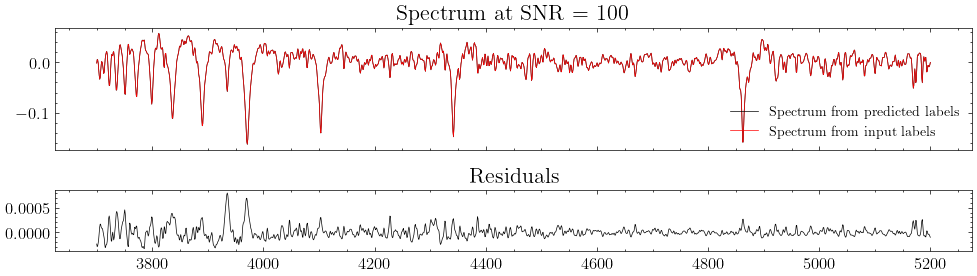

In [22]:
plot_spec(10) # well-fitted region for reference
plot_spec(2) # 0.8 and 0.2 case
plot_spec(np.argmax(true_100[:,0])) # 1.0 and 0 case

## Testing different label formulations

In [13]:
f2 = "sfh_1000_2bins_20260322_170022"

# labels_original = fits.getdata(f"/avatar/vmehta/{f1}/{f1}_labels.fits")
# spec_original = np.load(f"/avatar/vmehta/{f1}/{f1}_snr100_spectra.npy")
labels_uniform = fits.getdata(f"/avatar/vmehta/{f2}/{f2}_labels.fits")
spec_uniform = np.load(f"/avatar/vmehta/{f2}/{f2}_snr100_spectra.npy")
# model_original = pkl.load(open(f"/avatar/vmehta/{f1}/bounds-model/snr100_model.pkl", "rb"))
model_uniform = pkl.load(open(f"/avatar/vmehta/{f2}/bounds-model/snr100_model.pkl", "rb"))

/tmp/ipykernel_976600/2834936963.py:8: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  model_uniform = pkl.load(open(f"/avatar/vmehta/{f2}/bounds-model/snr100_model.pkl", "rb"))


In [14]:
def get_coeffs(model, idx, x):
    const = model['theta'][idx,0]
    linear1 = model['theta'][idx,1]
    linear2 = model['theta'][idx,2]
    square1 = model['theta'][idx,3]
    cross = model['theta'][idx,4]
    square2 = model['theta'][idx,5]
    return const + linear1*x + linear2*(1-x) + square1*x**2 + cross*x*(1-x) + square2*(1-x)**2

/tmp/ipykernel_17109/1483131413.py:12: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  model = pkl.load(open(f"/avatar/vmehta/{file}/bounds-model/snr{snr}_model.pkl", "rb"))


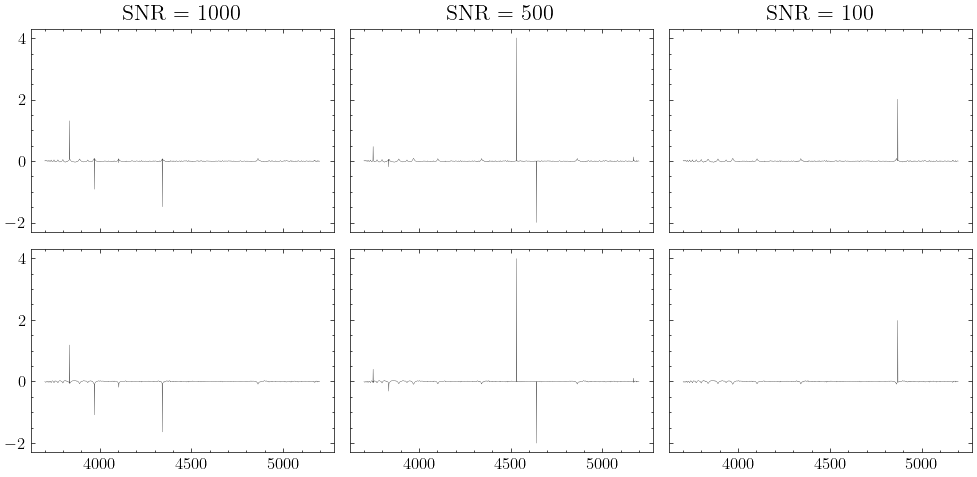

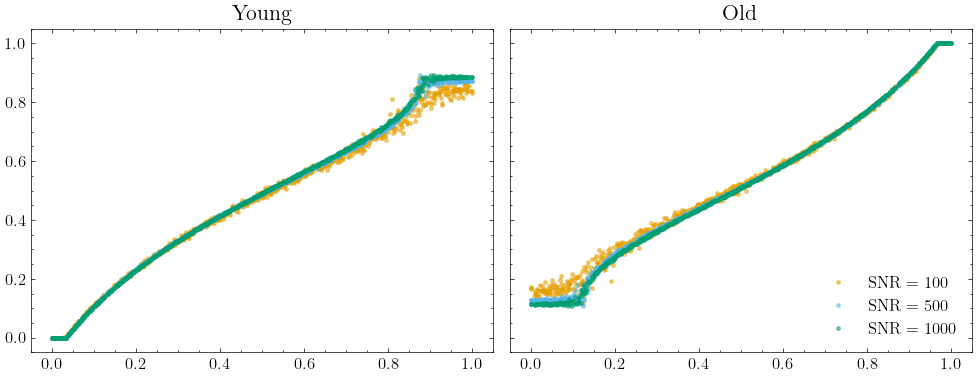

In [ ]:
file = "sfh_1000_20260306_211651"
plot_coeffs(which='bounds')
plot_labels(which='bounds')

### Testing a set uniform label formulation with correct input info

In [34]:
import sys
from pathlib import Path

# Find repo root robustly, then add code/src to Python path
cwd = Path.cwd().resolve()
repo_root = next(p for p in [cwd, *cwd.parents] if (p / "code" / "src").exists())
src_path = repo_root / "code" / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from AnniesLasso.thecannon.model import CannonModel

In [40]:
file = 'sfh_1000_2bins_20260323_140648'

model_path = Path(f"/avatar/vmehta/{file}/log-model/snr1000_model.pkl")
model = CannonModel.read(str(model_path))

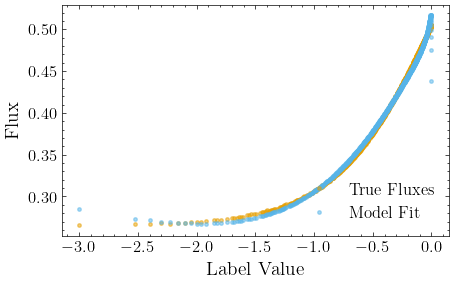

In [41]:
plt.figure(figsize=(5,3))
plt.plot(model.training_set_labels[:,0], model.training_set_flux[:,300], '.', alpha=0.5, markersize=5, label = 'True Fluxes')
plt.plot(model.training_set_labels[:,0], model.__call__(model.training_set_labels)[:,300], '.', alpha=0.5, markersize=5, label = 'Model Fit')
plt.xlabel('Label Value')
plt.ylabel('Flux')
plt.legend(loc='lower right')
plt.show()

/tmp/ipykernel_28514/2386031875.py:14: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  model = pkl.load(open(f"/avatar/vmehta/{file}/snr{snr}_model.pkl", "rb"))


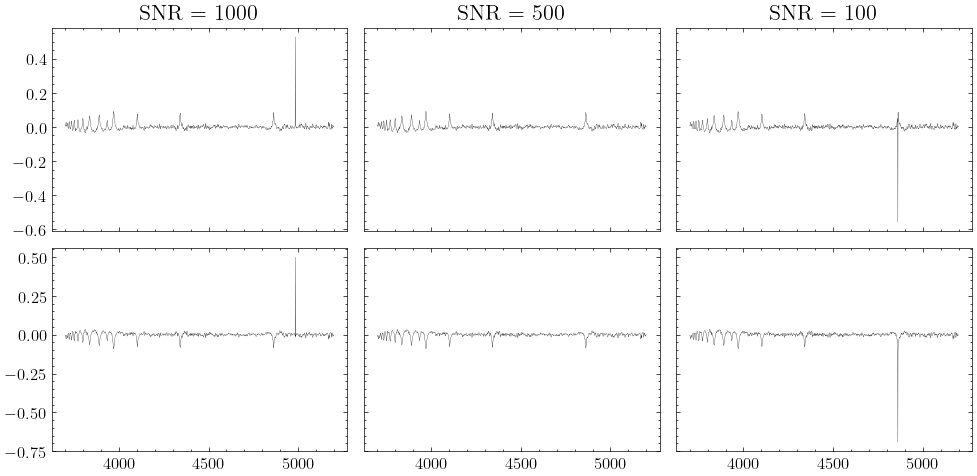

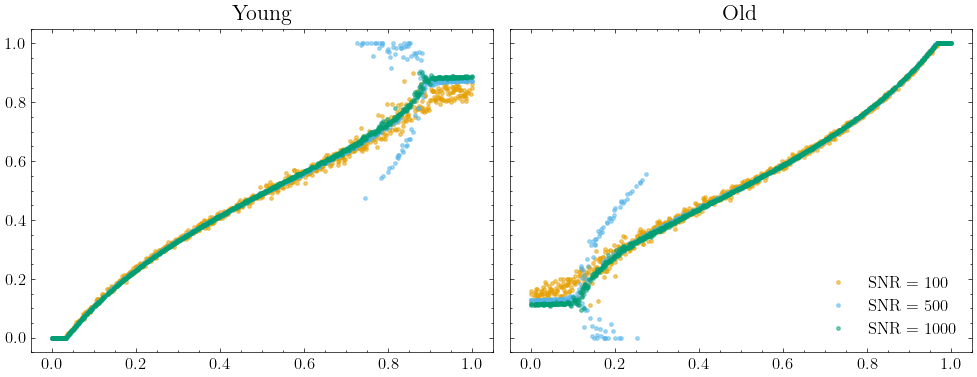

In [ ]:
plot_coeffs(which=None)
plot_labels(which=None)